# Transformer-Based Summarization — IndoBART
Abstractive summarization menggunakan `gaduhhartawan/indobart-base`.

**Objektif:**
1. **Summary quality** — ROUGE-1, ROUGE-2, ROUGE-L
2. **Contextual understanding** — contoh kualitatif
3. **Computational efficiency** — waktu inferensi

Input: `data_final.csv`

---
## Instalasi & Import

In [1]:
!pip install transformers sentencepiece rouge-score -q

In [2]:
import re
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer
from rouge_score import rouge_scorer
from tqdm import tqdm
tqdm.pandas()

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Device: cuda


---
## Load Dataset

In [3]:
df = pd.read_csv('/kaggle/input/datasets/nazhifberlian/nlp-wikipedia-summarization/data_final.csv', encoding='utf-8-sig')

print(f'Dataset dimuat: {len(df)} baris, {len(df.columns)} kolom')
print(f'Kolom: {list(df.columns)}')
print(f'\nDistribusi kategori:')
print(df['category'].value_counts().to_string())

Dataset dimuat: 12754 baris, 8 kolom
Kolom: ['global_id', 'id', 'title', 'category', 'article_text', 'body_word_count', 'lead_paragraph', 'lead_word_count']

Distribusi kategori:
category
sejarah     1986
arts        1975
artis       1971
kuliner     1958
tech        1728
biografi    1701
sains       1435


---
## 1. Preprocessing Teks

### 1a. Fungsi Pembersihan
**Identik dengan extractive approach** — hapus noise tanpa mengubah isi kalimat agar ROUGE tetap adil.

In [ ]:
def clean_text(text):
    text = str(text)
    text = re.sub(r'\[\d+\]', '', text)                      # hapus referensi [1], [2]
    text = re.sub(r'={2,}.*?={2,}', '', text)                # hapus == heading ==
    text = re.sub(r'http\S+|www\.\S+', '', text)             # hapus URL
    text = re.sub(r'\{\{.*?\}\}', '', text, flags=re.DOTALL) # hapus {{template}}
    text = text.replace('\u201c', '"').replace('\u201d', '"')
    text = text.replace('\u2018', "'").replace('\u2019', "'")
    text = text.replace('\u2013', '-').replace('\u2014', '-')
    text = re.sub(r'\s+', ' ', text)                         # rapikan spasi/newline
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s,.]", "", text) # hapus semua karakter selain huruf, angka, spasi, koma, titik
    return text.strip()

df['clean_text'] = df['article_text'].apply(clean_text)

print('Preprocessing selesai.')
print(f'\nContoh hasil (200 karakter):')
print(df['clean_text'].iloc[0][:200])

Preprocessing selesai.

Contoh hasil (200 karakter):
keberadaan penyanyi cilik di indonesia telah eksis sejak era 60an. pada saat itu sudah ada beberapa penyanyi anakanak seperti fenty effendy, anna mathovani, atau nenny triana. namun yang bisa dibilang


### 1b. Re-filter Artikel Pendek

In [5]:
df['body_word_count'] = df['clean_text'].str.split().str.len()

MIN_WORDS = 100

before = len(df)
df = df[df['body_word_count'] >= MIN_WORDS].reset_index(drop=True)

print(f'Sebelum filter: {before} baris')
print(f'Sesudah filter: {len(df)} baris')
print(f'\nStatistik panjang artikel:')
print(df['body_word_count'].describe().round(0).to_string())

Sebelum filter: 12754 baris
Sesudah filter: 12644 baris

Statistik panjang artikel:
count    12644.0
mean       452.0
std        484.0
min        100.0
25%        182.0
50%        302.0
75%        538.0
max      11947.0


---
## 2. Load Model IndoBART
IndoBART (IndoNLG) adalah BART yang dilatih pada korpus Indonesia meliputi Wikipedia, news, dan Twitter. Cocok untuk summarization teks bahasa Indonesia.

In [6]:
INDOBART_MODEL_NAME = 'gaduhhartawan/indobart-base'

print(f'Memuat tokenizer dari {INDOBART_MODEL_NAME}...')
tokenizer = AutoTokenizer.from_pretrained(INDOBART_MODEL_NAME)

print('Memuat model...')
model = AutoModelForSeq2SeqLM.from_pretrained(INDOBART_MODEL_NAME).to(DEVICE)
model.eval()

print(f'Model siap | Parameter: {model.num_parameters():,}')

Memuat tokenizer dari gaduhhartawan/indobart-base...


config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Please make sure the generation config includes `forced_bos_token_id=0`. 


Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/356 [00:00<?, ?B/s]

Model siap | Parameter: 406,290,432


---
## 3. Fungsi Summarization

### 3a. Fungsi Generik Summarize

In [7]:
MAX_INPUT_TOKENS  = 512
MAX_OUTPUT_TOKENS = 128
MIN_OUTPUT_TOKENS = 30

def summarize_transformer(text, prefix=''):
    input_text = prefix + text

    inputs = tokenizer(
        input_text,
        return_tensors='pt',
        max_length=MAX_INPUT_TOKENS,
        truncation=True,
        padding=False
    ).to(DEVICE)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=MAX_OUTPUT_TOKENS,
            min_new_tokens=MIN_OUTPUT_TOKENS,
            num_beams=4,
            early_stopping=True,
            no_repeat_ngram_size=3,
            length_penalty=1.0
        )

    summary = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    return summary.strip()

### 3b. Chunking untuk Artikel Panjang
Model transformer punya batasan panjang input (512 token). Artikel yang lebih panjang perlu dipecah dulu.

In [8]:
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import sent_tokenize

def split_sentences(text):
    sentences = sent_tokenize(text)
    return [s.strip() for s in sentences if len(s.split()) >= 4]

MAX_SENTENCES_PER_CHUNK = 20

def chunk_sentences(sentences, max_per_chunk=MAX_SENTENCES_PER_CHUNK):
    return [sentences[i:i+max_per_chunk] for i in range(0, len(sentences), max_per_chunk)]

def summarize_with_chunking(text, prefix=''):
    sentences = split_sentences(text)

    if len(sentences) <= MAX_SENTENCES_PER_CHUNK:
        return summarize_transformer(text, prefix)

    chunks = chunk_sentences(sentences)
    chunk_summaries = []
    for chunk in chunks:
        chunk_text = ' '.join(chunk)
        chunk_summaries.append(summarize_transformer(chunk_text, prefix))

    combined = ' '.join(chunk_summaries)
    return summarize_transformer(combined, prefix)

print('=== Demo IndoBART ===')
print(summarize_with_chunking(df['clean_text'].iloc[0]))

=== Demo IndoBART ===
Keberadaan penyanyi cilik di indonesia telah eksis sejak era 60an. pada saat itu sudah ada beberapa penyelewengan anakanak seperti fenty effendy, anna mathovani, atau nenny triana. namun yang bisa dibilang pionirnya adalah adi bing slamet dan ira maya sopha. ketika tren lawak tunggal mulai menjamur di pertelevisian ind


---
## 4. Generate Ringkasan untuk Seluruh Dataset

In [9]:
print('Generating ringkasan IndoBART...')
start = time.time()

df['summary_indobart'] = df['clean_text'].progress_apply(
    lambda x: summarize_with_chunking(x, prefix='')
)

time_indobart = time.time() - start
print(f'Selesai dalam {time_indobart:.1f} detik ({time_indobart/len(df):.2f} detik/artikel)')
print(f'\nContoh:')
print(f'JUDUL    : {df["title"].iloc[0]}')
print(f'RINGKASAN: {df["summary_indobart"].iloc[0]}')

Generating ringkasan IndoBART...


100%|██████████| 12644/12644 [11:12:27<00:00,  3.19s/it]

Selesai dalam 40347.9 detik (3.19 detik/artikel)

Contoh:
JUDUL    : Daftar artis cilik Indonesia
RINGKASAN: Keberadaan penyanyi cilik di indonesia telah eksis sejak era 60an. pada saat itu sudah ada beberapa penyelewengan anakanak seperti fenty effendy, anna mathovani, atau nenny triana. namun yang bisa dibilang pionirnya adalah adi bing slamet dan ira maya sopha. ketika tren lawak tunggal mulai menjamur di pertelevisian ind


---
## 5. Simpan Hasil

In [10]:
output_cols = ['global_id', 'title', 'category', 'summary_indobart', 'lead_paragraph', 'body_word_count']
hasil = df[[c for c in output_cols if c in df.columns]]

hasil.to_csv('hasil_summary_indobart.csv', index=False, encoding='utf-8-sig')
print(f'Tersimpan: hasil_summary_indobart.csv ({len(hasil)} baris)')

for i in range(min(3, len(hasil))):
    print(f'\n[{hasil["category"].iloc[i]}] {hasil["title"].iloc[i]}')
    print(f'  IndoBART: {hasil["summary_indobart"].iloc[i][:120]}...')

Tersimpan: hasil_summary_indobart.csv (12644 baris)

[artis] Daftar artis cilik Indonesia
  IndoBART: Keberadaan penyanyi cilik di indonesia telah eksis sejak era 60an. pada saat itu sudah ada beberapa penyelewengan anakan...

[artis] A. Sarosa
  IndoBART: ali sarosa lahir pada tanggal 20 februari 1918 di banyumas, jawa tengah. beliau menyelesaikan pendidikannya di mulo dan ...

[artis] Onadio Leonardo
  IndoBART: onadio menjalin hubungan asmara berbeda agama dengan beby prisillia gustiansyahyang kini dikenal sebagai beby leonardo. ...


---
## 6. Evaluasi ROUGE
Metrik: ROUGE-1, ROUGE-2, ROUGE-L dengan ground truth `lead_paragraph`.

In [11]:
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=False)

r1, r2, rl = [], [], []
for pred, ref in zip(df['summary_indobart'], df['lead_paragraph']):
    s = scorer.score(str(ref), str(pred))
    r1.append(s['rouge1'].fmeasure)
    r2.append(s['rouge2'].fmeasure)
    rl.append(s['rougeL'].fmeasure)

rouge_indobart = (np.mean(r1), np.mean(r2), np.mean(rl))

print(f'{'Metrik':<10} | {'Skor':>8}')
print('-' * 22)
print(f'{'ROUGE-1':<10} | {rouge_indobart[0]:>8.4f}')
print(f'{'ROUGE-2':<10} | {rouge_indobart[1]:>8.4f}')
print(f'{'ROUGE-L':<10} | {rouge_indobart[2]:>8.4f}')

Metrik     |     Skor
----------------------
ROUGE-1    |   0.1649
ROUGE-2    |   0.0375
ROUGE-L    |   0.1128


### 6a. ROUGE-L per Kategori

In [12]:
rows = []
for kategori in sorted(df['category'].unique()):
    sub = df[df['category'] == kategori]
    scores = [scorer.score(str(ref), str(pred))['rougeL'].fmeasure
              for pred, ref in zip(sub['summary_indobart'], sub['lead_paragraph'])]
    rows.append({'kategori': kategori, 'jumlah': len(sub), 'rougeL': np.mean(scores)})

tabel = pd.DataFrame(rows).sort_values('rougeL', ascending=False)
print('ROUGE-L per kategori (IndoBART):')
print(tabel.round(4).to_string(index=False))

ROUGE-L per kategori (IndoBART):
kategori  jumlah  rougeL
biografi    1679  0.1171
 sejarah    1976  0.1161
 kuliner    1944  0.1145
   artis    1947  0.1129
    tech    1716  0.1122
    arts    1965  0.1103
   sains    1417  0.1048


### 6b. Computational Efficiency

In [13]:
print('Computational Efficiency — IndoBART:')
print('=' * 45)
print(f'Total waktu   : {time_indobart:.1f} detik')
print(f'Per artikel   : {time_indobart/len(df):.2f} detik')
print(f'Jumlah artikel: {len(df)}')
print(f'Parameter     : {model.num_parameters():,}')

Computational Efficiency — IndoBART:
Total waktu   : 40347.9 detik
Per artikel   : 3.19 detik
Jumlah artikel: 12644
Parameter     : 406,290,432


---
## 7. Visualisasi

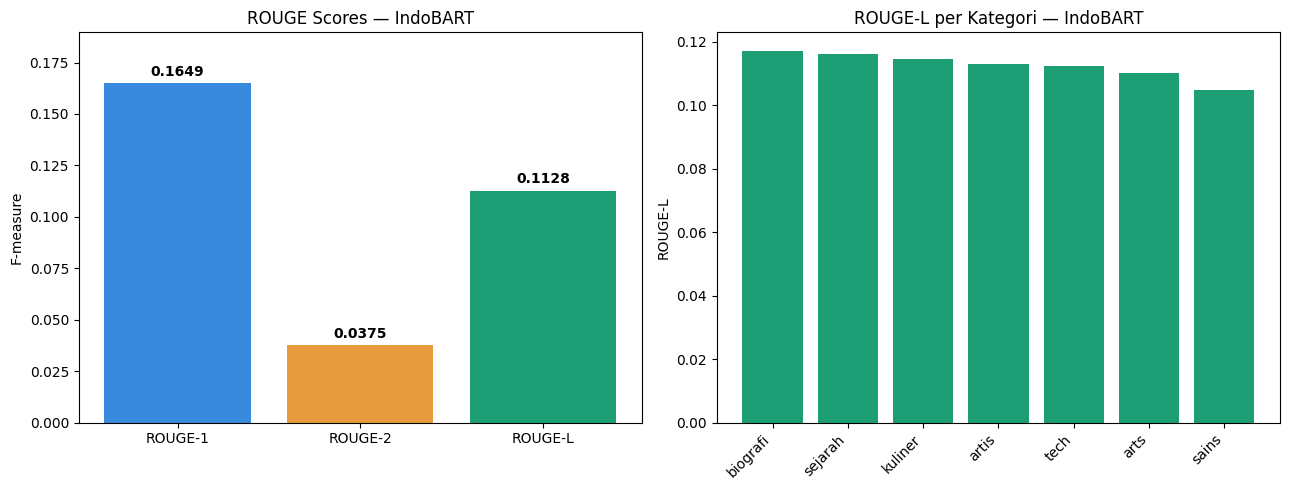

Grafik tersimpan: indobart_results.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: ROUGE scores
ax = axes[0]
metrics = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']
vals = list(rouge_indobart)
bars = ax.bar(metrics, vals, color=['#378ADD', '#E89B3C', '#1D9E75'])
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{v:.4f}', ha='center', va='bottom', fontweight='bold')
ax.set_title('ROUGE Scores — IndoBART')
ax.set_ylabel('F-measure')
ax.set_ylim(0, max(vals) * 1.15)

# Plot 2: ROUGE-L per kategori
ax2 = axes[1]
xk = np.arange(len(tabel))
ax2.bar(xk, tabel['rougeL'], color='#1D9E75')
ax2.set_xticks(xk)
ax2.set_xticklabels(tabel['kategori'], rotation=45, ha='right')
ax2.set_title('ROUGE-L per Kategori — IndoBART')
ax2.set_ylabel('ROUGE-L')

plt.tight_layout()
plt.savefig('indobart_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik tersimpan: indobart_results.png')

---
## 8. Contoh Kualitatif

In [15]:
N_CONTOH = 3
sample_idx = df.sample(N_CONTOH, random_state=42).index

for i, idx in enumerate(sample_idx):
    row = df.loc[idx]
    print(f'{'='*70}')
    print(f'Artikel {i+1}: [{row["category"]}] {row["title"]}')
    print(f'Ground Truth (lead_paragraph):')
    print(f'  {str(row["lead_paragraph"])[:200]}...')
    print(f'IndoBART:')
    print(f'  {row["summary_indobart"][:200]}')
    print()

Artikel 1: [biografi] Mardiyanto
Ground Truth (lead_paragraph):
  Mardiyanto (lahir 21 November 1947) adalah politisi dan mantan jenderal Indonesia. Ia menjabat sebagai Gubernur Jawa Tengah mulai tahun 1998, dan terpilih kembali sebagai calon dari partai PDI-P pada ...
IndoBART:
  Mardiyanto adalah pemimpin departemen taktik di akademi militer. pada tahun 1997 hingga 1998 ia menjabat sebagai panglima kodam ivdiponegoro. menteri dalam negeri pada tanggal 28 agustus 2007, ia ditu

Artikel 2: [arts] Petak umpet
Ground Truth (lead_paragraph):
  Petak umpet adalah sejenis permainan cari dan sembunyi yang bisa dimainkan oleh minimal dua orang yang umumnya dilakukan di luar ruang. Nama permainan ini berbeda-beda di setiap daerah. Petak umpet me...
IndoBART:
  Permainan petak umpet digunakan sebagai metode pengajaran kemampuan berhitung pada anak dan untuk bermain kerja sama dalam tim dengan temannya. beberapa manfaat lain bagi pemain adalah mengembangkan k

Artikel 3: [kuliner] Industri susu 